# Khai Phá Dữ Liệu (Exploratory Data Analysis - EDA)
## Đề tài: Multimodal Data Mining: Combining Unstructured Data and Market Basket Analysis based on the RFM model
**Nhóm thực hiện**: Nhóm 5 (Môn Khoa học Dữ liệu)

### Giới thiệu dự án
Notebook này thực hiện khai phá dữ liệu (EDA) trên tập dữ liệu Shopee Skincare bao gồm lịch sử giao dịch mua sắm, đánh giá của khách hàng, thuộc tính sản phẩm và thông tin của shop. Mục tiêu nhằm hiểu rõ cấu trúc dữ liệu, các thuộc tính thời gian, phân phối biến số, và kiểm chứng tính khả thi của các mô hình phân khúc khách hàng (RFM) và phân tích giỏ hàng (MBA) tiếp theo.

### Các tập dữ liệu bao gồm:
1. `data_reviews_purchase.csv`: Lịch sử giao dịch, đánh giá (1-5 sao) và bình luận văn bản của khách hàng.
2. `data_product.csv`: Danh mục sản phẩm (giá, lượt bán, thương hiệu, loại da, mô tả sản phẩm,...).
3. `data_product_attribute.csv`: Thuộc tính sản phẩm chi tiết (thành phần, công dụng, thiết kế bao bì, dung tích,...).
4. `data_shop.csv`: Thông tin người bán (lượt theo dõi, trạng thái xác minh, điểm đánh giá của shop).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Cấu hình vẽ đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 1. Tải và Khảo Sát Tổng Quan Dữ Liệu

In [2]:
df_reviews = pd.read_csv('../dataset/before_EDA/data_reviews_purchase.csv')
df_products = pd.read_csv('../dataset/before_EDA/data_product.csv')
df_attributes = pd.read_csv('../dataset/before_EDA/data_product_attribute.csv')
df_shops = pd.read_csv('../dataset/before_EDA/data_shop.csv')

print("=== Kích thước các tập dữ liệu gốc ===")
print(f"  Giao dịch & Đánh giá: {df_reviews.shape[0]:,} dòng x {df_reviews.shape[1]} cột")
print(f"  Danh mục Sản phẩm   : {df_products.shape[0]:,} dòng x {df_products.shape[1]} cột")
print(f"  Thuộc tính Chi tiết : {df_attributes.shape[0]:,} dòng x {df_attributes.shape[1]} cột")
print(f"  Thông tin Cửa hàng  : {df_shops.shape[0]:,} dòng x {df_shops.shape[1]} cột")

=== Kích thước các tập dữ liệu gốc ===
  Giao dịch & Đánh giá: 369,099 dòng x 10 cột
  Danh mục Sản phẩm   : 2,244 dòng x 24 cột
  Thuộc tính Chi tiết : 2,244 dòng x 11 cột
  Thông tin Cửa hàng  : 1,291 dòng x 11 cột


In [3]:
print("\n--- Thông tin tập Giao dịch & Đánh giá ---")
print(df_reviews.info())
display(df_reviews.head(3))


--- Thông tin tập Giao dịch & Đánh giá ---
<class 'pandas.DataFrame'>
RangeIndex: 369099 entries, 0 to 369098
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         369099 non-null  int64  
 1   user_id            369099 non-null  int64  
 2   product_id         369099 non-null  int64  
 3   rating             369099 non-null  int64  
 4   product_name_x     369099 non-null  str    
 5   cmt_date           369099 non-null  str    
 6   shop_id            369099 non-null  int64  
 7   variation_x        369099 non-null  str    
 8   product_quality    369099 non-null  float64
 9   processed_comment  359418 non-null  str    
dtypes: float64(1), int64(5), str(4)
memory usage: 28.2 MB
None


,Unnamed: 0,user_id,product_id,rating,product_name_x,cmt_date,shop_id,variation_x,product_quality,processed_comment
0,0,0,0,4,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-06 12:28:25,0,Simple,4.0,mùi hương ko bít dành cho da tùy da công da an...
1,1,1,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-03 12:18:12,0,Simple,5.0,mùi nhẹ dành cho da mọi loại da công_dụng rửa ...
2,2,2,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-05 04:57:08,0,Simple,5.0,công_dụng rửa mặt_hàng giao rất nhanh sản_phẩm...


In [4]:
print("\n--- Thông tin tập Danh mục Sản phẩm ---")
print(df_products.info())
display(df_products.head(2))


--- Thông tin tập Danh mục Sản phẩm ---
<class 'pandas.DataFrame'>
RangeIndex: 2244 entries, 0 to 2243
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   avg_star               2244 non-null   float64
 1   num_sold_time          2244 non-null   int64  
 2   price                  2244 non-null   float64
 3   variation              2244 non-null   str    
 4   product_id             2244 non-null   int64  
 5   shop_id                2244 non-null   int64  
 6   product_name           2244 non-null   str    
 7   brand                  2244 non-null   str    
 8   storage                2244 non-null   float64
 9   origin                 2244 non-null   str    
 10  type                   2244 non-null   str    
 11  skin_kind              2244 non-null   str    
 12  is_5_star              2244 non-null   int64  
 13  is_4_star              2244 non-null   int64  
 14  is_3_star              224

,avg_star,num_sold_time,price,variation,product_id,shop_id,product_name,brand,storage,origin,...,is_3_star,is_2_star,is_1_star,is_commented,is_image,num_rating,processed_description,expiry,send_from,image_path
0,4.8,185700,99000.0,one_variation,0,0,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,simple,18081.0,no_origin,...,1200,640,1600,42200,37900,66840,ưu_điểm nổi_trội sữa rửa mặt simple lành_tính ...,no_expiry,tp. hồ chí minh,111138057_8587034871.jpg
1,4.8,102600,99000.0,one_variation,1,0,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...,simple,9857.0,no_origin,...,709,320,723,22700,20400,36552,ưu_điểm nổi_trội sữa rửa mặt simple giúp kiềm ...,no_expiry,tp. hồ chí minh,111138057_8287055694.jpg


### Phân Tích Giá Trị Thiếu (NaN)

In [5]:
print("=== Tỷ lệ phần trăm giá trị thiếu (NaN) ===")
for name, df in [('Reviews', df_reviews), ('Products', df_products), 
                 ('Attributes', df_attributes), ('Shops', df_shops)]:
    null_pct = df.isnull().mean() * 100
    null_pct = null_pct[null_pct > 0]
    print(f"\n  Tập {name}:")
    if null_pct.empty:
        print("    Không có cột nào bị thiếu dữ liệu.")
    else:
        for col, pct in null_pct.items():
            print(f"    Cột {col}: thiếu {pct:.2f}%")

=== Tỷ lệ phần trăm giá trị thiếu (NaN) ===

  Tập Reviews:
    Cột processed_comment: thiếu 2.62%

  Tập Products:
    Không có cột nào bị thiếu dữ liệu.

  Tập Attributes:
    Cột ingredient: thiếu 18.23%
    Cột feature: thiếu 1.78%
    Cột skin_type: thiếu 37.08%
    Cột capacity: thiếu 42.96%
    Cột design: thiếu 58.56%
    Cột brand: thiếu 17.07%
    Cột expiry: thiếu 69.88%
    Cột origin: thiếu 41.35%

  Tập Shops:
    Không có cột nào bị thiếu dữ liệu.


## 2. Khai Phá Tập Giao Dịch & Đánh Giá khách hàng

C:\Users\david\AppData\Local\Temp\ipykernel_22360\2078375148.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reviews, x='rating', palette='viridis')


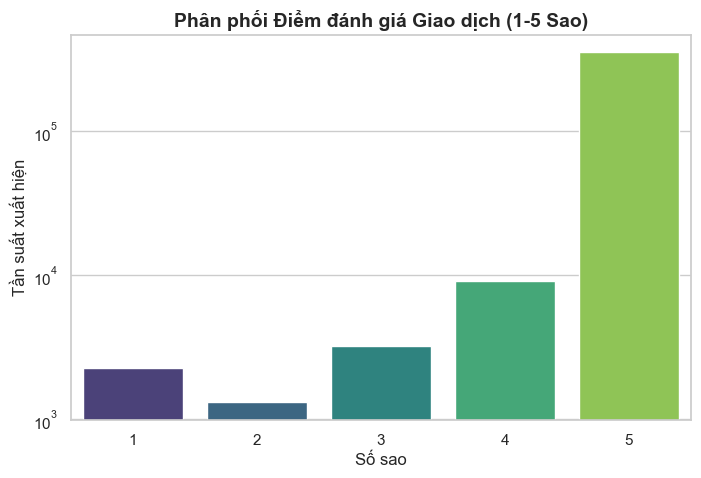

  Đánh giá 1 sao: 2,271 lượt (0.62%)
  Đánh giá 2 sao: 1,308 lượt (0.35%)
  Đánh giá 3 sao: 3,207 lượt (0.87%)
  Đánh giá 4 sao: 9,147 lượt (2.48%)
  Đánh giá 5 sao: 353,166 lượt (95.68%)


In [6]:
# Vẽ phân phối điểm đánh giá (Rating)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_reviews, x='rating', palette='viridis')
plt.title('Phân phối Điểm đánh giá Giao dịch (1-5 Sao)', fontsize=14, fontweight='bold')
plt.xlabel('Số sao')
plt.ylabel('Tần suất xuất hiện')
plt.yscale('log') # Thang logarit vì điểm 5 sao quá vượt trội
plt.show()

rating_counts = df_reviews['rating'].value_counts().sort_index()
for r, cnt in rating_counts.items():
    print(f"  Đánh giá {r} sao: {cnt:,} lượt ({cnt/len(df_reviews)*100:.2f}%)")

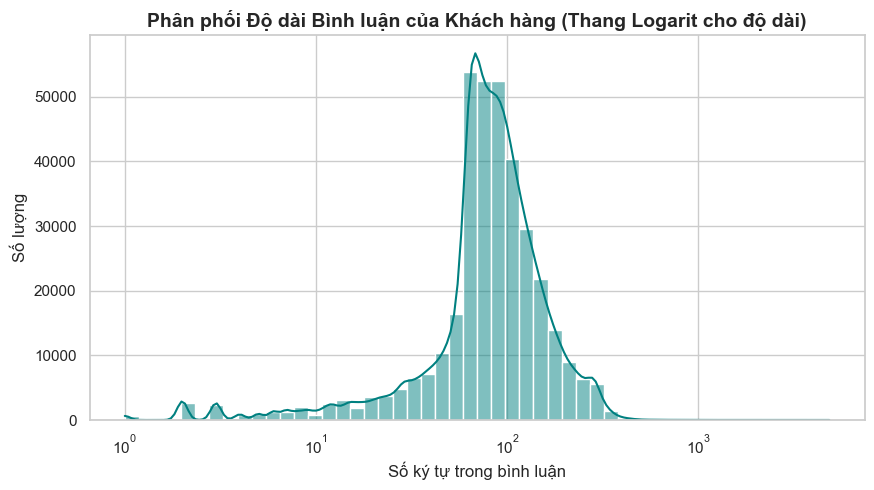

Thống kê độ dài bình luận:
count    369099.000000
mean         92.351935
std          61.635129
min           0.000000
25%          61.000000
50%          81.000000
75%         114.000000
max        4871.000000
Name: comment_length, dtype: float64


In [7]:
# Độ dài bình luận văn bản (processed_comment)
df_reviews['comment_length'] = df_reviews['processed_comment'].fillna('').str.len()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_reviews[df_reviews['comment_length'] > 0], x='comment_length', 
             bins=50, kde=True, color='teal', log_scale=(True, False))
plt.title('Phân phối Độ dài Bình luận của Khách hàng (Thang Logarit cho độ dài)', fontsize=14, fontweight='bold')
plt.xlabel('Số ký tự trong bình luận')
plt.ylabel('Số lượng')
plt.show()

print("Thống kê độ dài bình luận:")
print(df_reviews['comment_length'].describe())

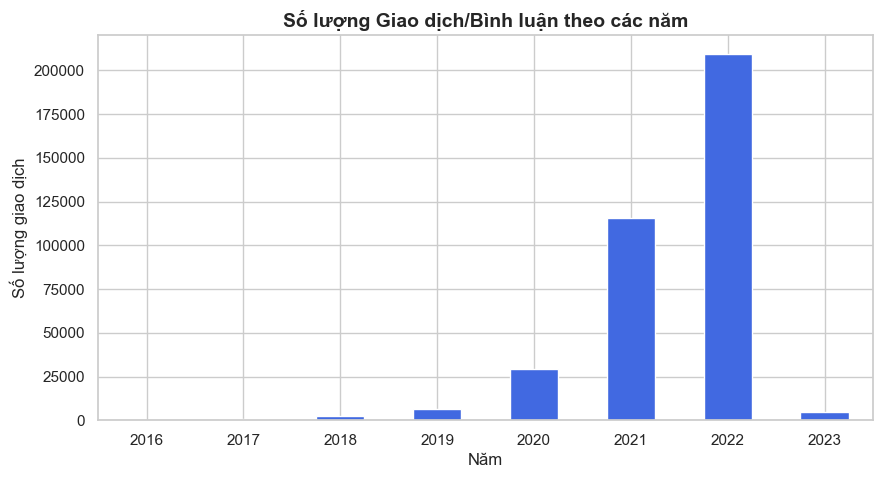

In [8]:
# Chuyển đổi và phân tích thời gian giao dịch
df_reviews['cmt_date'] = pd.to_datetime(df_reviews['cmt_date'])
df_reviews['year_month'] = df_reviews['cmt_date'].dt.to_period('M')

# Vẽ xu hướng giao dịch theo năm
plt.figure(figsize=(10, 5))
df_reviews['cmt_date'].dt.year.value_counts().sort_index().plot(kind='bar', color='royalblue')
plt.title('Số lượng Giao dịch/Bình luận theo các năm', fontsize=14, fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Số lượng giao dịch')
plt.xticks(rotation=0)
plt.show()

## 3. Khai Phá Danh Mục Sản Phẩm (Products)

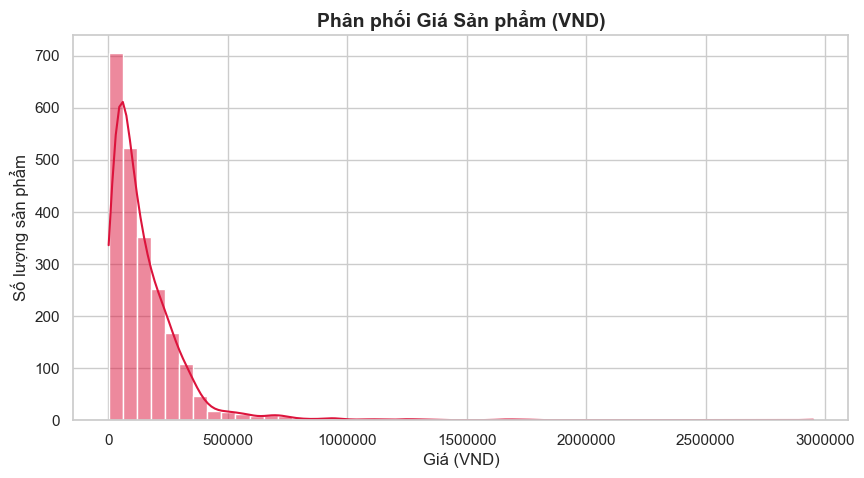

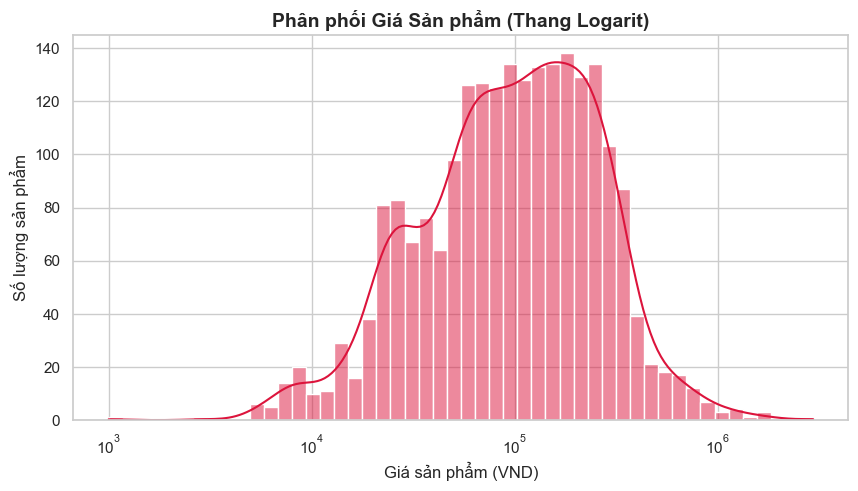

Thống kê giá sản phẩm:
count    2.244000e+03
mean     1.487148e+05
std      1.676588e+05
min      1.000000e+03
25%      4.900000e+04
50%      1.000000e+05
75%      1.990000e+05
max      2.950000e+06
Name: price, dtype: float64


In [9]:
# Phân phối giá sản phẩm
plt.figure(figsize=(10, 5))
sns.histplot(data=df_products, x='price', bins=50, color='crimson', kde=True)
plt.title('Phân phối Giá Sản phẩm (VND)', fontsize=14, fontweight='bold')
plt.xlabel('Giá (VND)')
plt.ylabel('Số lượng sản phẩm')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Vẽ thang log do dữ liệu bị lệch (skewed)
plt.figure(figsize=(10, 5))
sns.histplot(data=df_products, x='price', bins=50, color='crimson', kde=True, log_scale=True)
plt.title('Phân phối Giá Sản phẩm (Thang Logarit)', fontsize=14, fontweight='bold')
plt.xlabel('Giá sản phẩm (VND)')
plt.ylabel('Số lượng sản phẩm')
plt.show()

print("Thống kê giá sản phẩm:")
print(df_products['price'].describe())

C:\Users\david\AppData\Local\Temp\ipykernel_22360\3628488425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma')


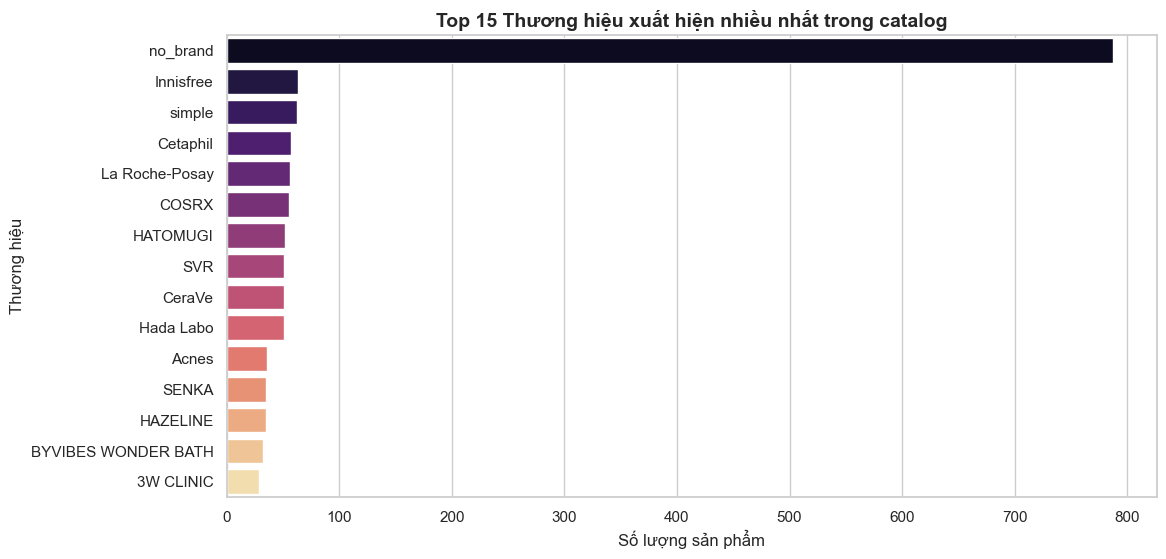

Tỷ lệ thương hiệu 'no_brand' chiếm trong danh mục:
  35.07%


In [10]:
# Top 15 thương hiệu sản phẩm xuất hiện nhiều nhất
plt.figure(figsize=(12, 6))
top_brands = df_products['brand'].value_counts().head(15)
sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma')
plt.title('Top 15 Thương hiệu xuất hiện nhiều nhất trong catalog', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng sản phẩm')
plt.ylabel('Thương hiệu')
plt.show()

print("Tỷ lệ thương hiệu 'no_brand' chiếm trong danh mục:")
no_brand_pct = (df_products['brand'] == 'no_brand').mean() * 100
print(f"  {no_brand_pct:.2f}%")

C:\Users\david\AppData\Local\Temp\ipykernel_22360\984573084.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_types.values, y=top_types.index, ax=axes[0], palette='Set2')
C:\Users\david\AppData\Local\Temp\ipykernel_22360\984573084.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_origins.values, y=top_origins.index, ax=axes[1], palette='Set2')


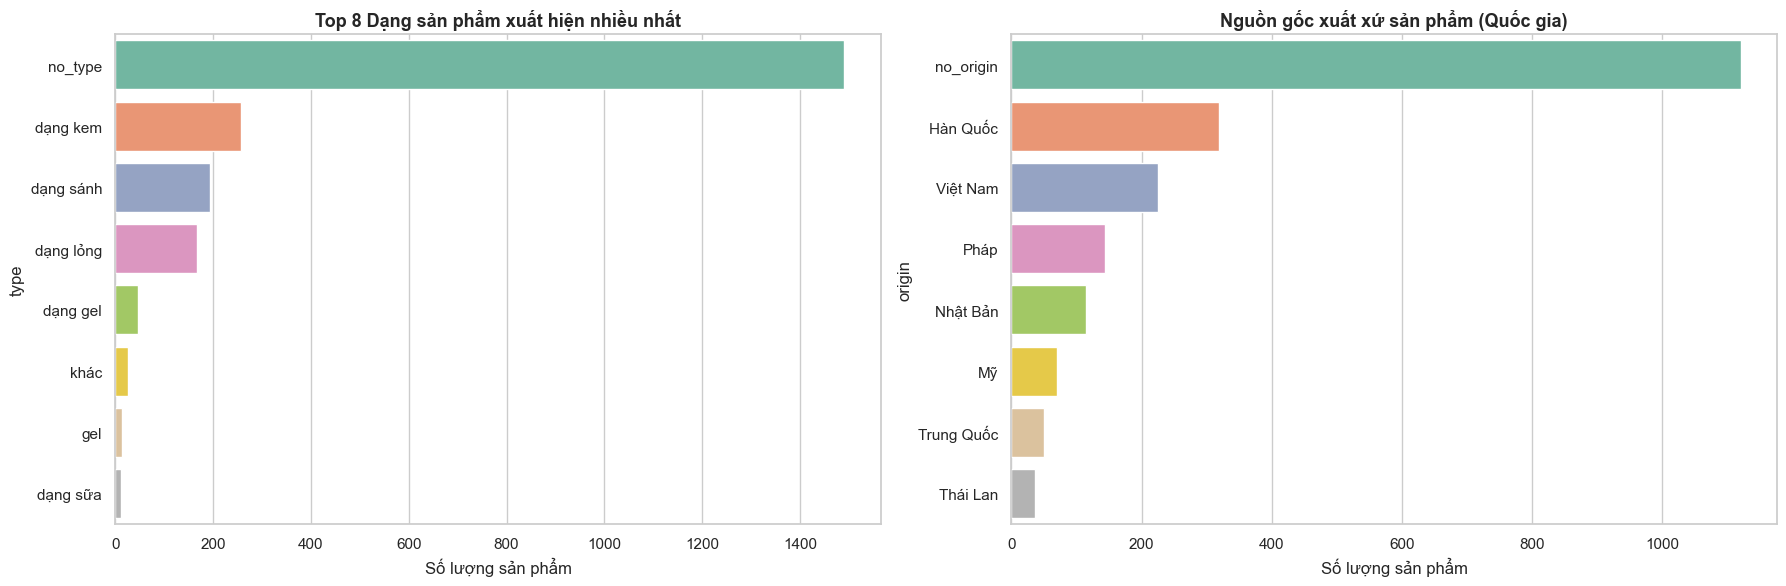

In [11]:
# Dạng sản phẩm (Type) và Nguồn gốc (Origin)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_types = df_products['type'].value_counts().head(8)
sns.barplot(x=top_types.values, y=top_types.index, ax=axes[0], palette='Set2')
axes[0].set_title('Top 8 Dạng sản phẩm xuất hiện nhiều nhất', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số lượng sản phẩm')

top_origins = df_products['origin'].value_counts().head(8)
sns.barplot(x=top_origins.values, y=top_origins.index, ax=axes[1], palette='Set2')
axes[1].set_title('Nguồn gốc xuất xứ sản phẩm (Quốc gia)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số lượng sản phẩm')

plt.tight_layout()
plt.show()

## 4. Khai Phá Dữ Liệu Cửa Hàng (Shops)

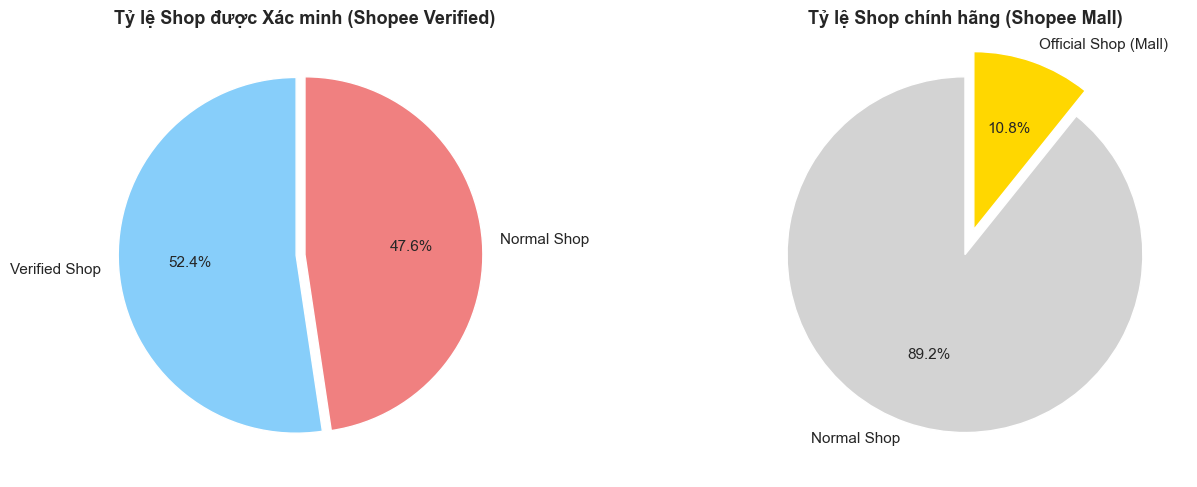

In [12]:
# Phân tích chỉ số cửa hàng
verified_counts = df_shops['is_shopee_verified'].value_counts()
official_counts = df_shops['is_official_shop'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(verified_counts, labels=['Verified Shop', 'Normal Shop'], autopct='%1.1f%%', 
            colors=['lightskyblue', 'lightcoral'], startangle=90, explode=(0.05, 0))
axes[0].set_title('Tỷ lệ Shop được Xác minh (Shopee Verified)', fontsize=13, fontweight='bold')

axes[1].pie(official_counts, labels=['Normal Shop', 'Official Shop (Mall)'], autopct='%1.1f%%', 
            colors=['lightgrey', 'gold'], startangle=90, explode=(0, 0.15))
axes[1].set_title('Tỷ lệ Shop chính hãng (Shopee Mall)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

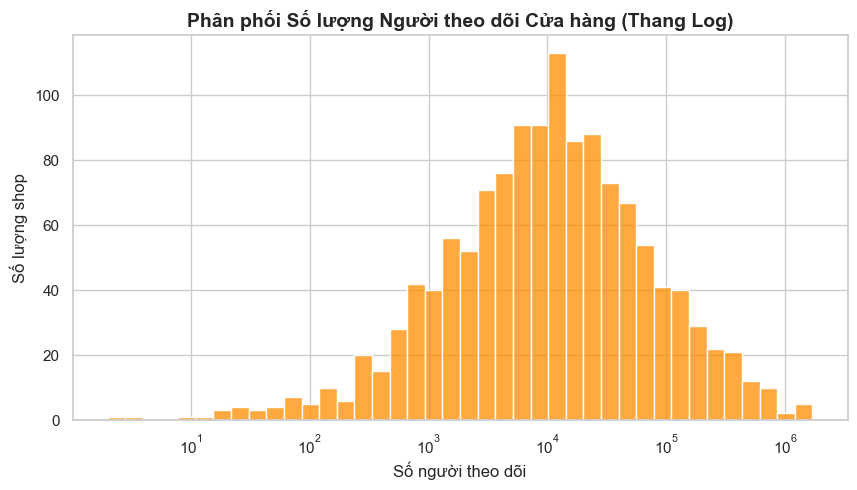

Thông số người theo dõi:
count    1.291000e+03
mean     5.169564e+04
std      1.391619e+05
min      2.000000e+00
25%      3.099500e+03
50%      1.075200e+04
75%      3.707350e+04
max      1.691046e+06
Name: follower_count, dtype: float64


In [13]:
# Phân phối số người theo dõi shop
plt.figure(figsize=(10, 5))
sns.histplot(data=df_shops, x='follower_count', bins=40, color='darkorange', log_scale=True)
plt.title('Phân phối Số lượng Người theo dõi Cửa hàng (Thang Log)', fontsize=14, fontweight='bold')
plt.xlabel('Số người theo dõi')
plt.ylabel('Số lượng shop')
plt.show()

print("Thông số người theo dõi:")
print(df_shops['follower_count'].describe())

## 5. Khảo Sát Tính Khả Thi Phục Vụ Modeling (RFM & MBA)
Tại đây chúng ta sẽ kiểm tra xem dữ liệu có đủ điều kiện để tính toán mô hình phân cụm hành vi RFM và khai thác luật kết hợp giỏ hàng (MBA) hay không.

In [14]:
# 1. Tần suất giao dịch của mỗi khách hàng (Frequency)
user_counts = df_reviews['user_id'].value_counts()
print("=== Tần suất giao dịch của mỗi khách hàng ===")
print(user_counts.describe())

users_gte2 = (user_counts >= 2).sum()
users_gte3 = (user_counts >= 3).sum()
print(f"  Số lượng người mua có >= 2 giao dịch: {users_gte2:,} người ({users_gte2/len(user_counts)*100:.2f}%)")
print(f"  Số lượng người mua có >= 3 giao dịch: {users_gte3:,} người ({users_gte3/len(user_counts)*100:.2f}%)")

=== Tần suất giao dịch của mỗi khách hàng ===
count    304708.000000
mean          1.211320
std           0.605394
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          20.000000
Name: count, dtype: float64
  Số lượng người mua có >= 2 giao dịch: 46,379 người (15.22%)
  Số lượng người mua có >= 3 giao dịch: 11,582 người (3.80%)


C:\Users\david\AppData\Local\Temp\ipykernel_22360\1554881484.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=basket_sizes.index[:10], y=basket_sizes.values[:10], palette='viridis')


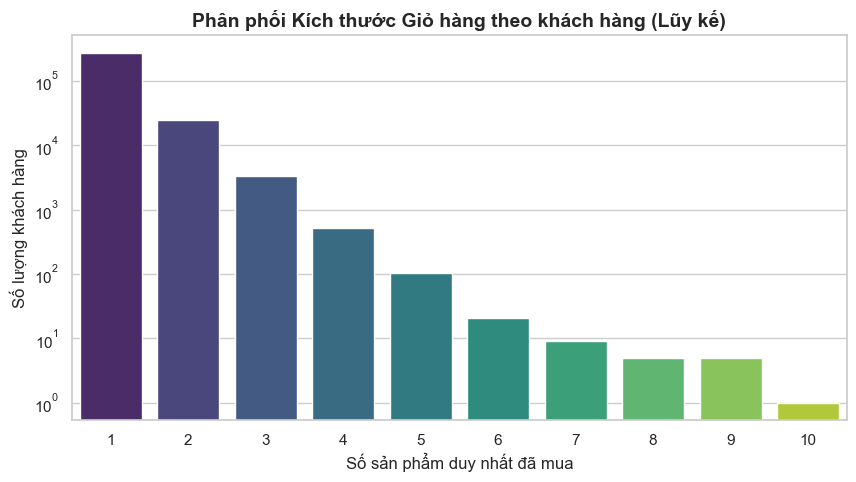

Phân phối kích thước giỏ hàng:
  Giỏ hàng kích thước 1: 276,231 khách hàng (90.65%)
  Giỏ hàng kích thước 2: 24,525 khách hàng (8.05%)
  Giỏ hàng kích thước 3: 3,292 khách hàng (1.08%)
  Giỏ hàng kích thước 4: 512 khách hàng (0.17%)
  Giỏ hàng kích thước 5: 104 khách hàng (0.03%)


In [15]:
# 2. Kích thước giỏ hàng tích lũy (User-Lifetime Basket size)
user_unique_products = df_reviews.groupby('user_id')['product_id'].nunique()
basket_sizes = user_unique_products.value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=basket_sizes.index[:10], y=basket_sizes.values[:10], palette='viridis')
plt.title('Phân phối Kích thước Giỏ hàng theo khách hàng (Lũy kế)', fontsize=14, fontweight='bold')
plt.xlabel('Số sản phẩm duy nhất đã mua')
plt.ylabel('Số lượng khách hàng')
plt.yscale('log')
plt.show()

print("Phân phối kích thước giỏ hàng:")
for size, cnt in basket_sizes.head(5).items():
    print(f"  Giỏ hàng kích thước {size}: {cnt:,} khách hàng ({cnt/len(user_unique_products)*100:.2f}%)")

## 6. Kết Luận Từ Quá Trình EDA

1. **Tập Giao dịch khách hàng**: Dữ liệu có kích thước đủ lớn (369K dòng) và hoàn toàn sạch sẽ, không có giá trị khuyết thiếu ở các cột định danh (`user_id`, `product_id`) và thời gian (`cmt_date`). Cột bình luận đánh giá (`processed_comment`) chứa 2.6% giá trị thiếu và sẽ được gán chuỗi rỗng trước khi đưa vào bộ nhúng/phân tích cảm xúc.
2. **Điểm đánh giá (Rating)**: Bị lệch cực kỳ nặng về phía điểm 5 sao (chiếm hơn 95% tập dữ liệu). Do đó, khi phân tích cảm xúc, chúng ta cần chuẩn hóa và kết hợp thông tin bình luận văn bản phi cấu trúc để tăng tính đa dạng.
3. **Tính khả thi của mô hình RFM**: Có độ trải rộng cực kỳ rộng về Recency (từ 0 đến 2,345 ngày) và Monetary (từ 1,000 VND đến hơn 4 triệu VND). Chỉ số Frequency phân bố chủ yếu ở mức 1 lần mua, nên mô hình K-Means++ sẽ hoạt động tốt nhất khi được kết hợp với điểm cảm xúc (Sentiment) làm chiều thứ 4 để tăng chất lượng cụm.
4. **Tính khả thi của mô hình giỏ hàng (MBA)**: Nếu nhóm theo ngày mua (Same-day transaction), giỏ hàng cực kỳ thưa (chỉ có 2,099 giỏ hàng có từ 2 sản phẩm trở lên). Tuy nhiên, nếu gom theo thời gian sống (User-Lifetime Basket), chúng ta thu được **28,477 giỏ hàng** có kích thước từ 2 sản phẩm trở lên. Đây là tập dữ liệu lý tưởng để chạy thuật toán luật kết hợp Apriori/FP-Growth phục vụ việc bán chéo sản phẩm chăm sóc da (Skincare) vốn có chu kỳ tái mua sắm dài.